# 02 - Part 1: Faithful Reproduction of the Stacking Ensemble
Reproduces the paper's six base classifiers (LR, DT, RF, XGBoost, NB, KNN) plus the 5-fold stacking ensemble, under two protocols:
- **Protocol A (as-published):** the 1025-row file, random 80/20 stratified split -- our best-effort faithful reproduction of what the paper describes.
- **Protocol B (de-duplicated):** the same pipeline on the 302 unique rows, to isolate the effect of the duplicate-row leakage identified in notebook 01.

See `src/part1_reproduction.py` docstring for the full list of documented assumptions (A1-A5) made where the paper is silent on implementation detail.

In [1]:
import sys, os
sys.path.append(os.path.abspath('../src'))
import pandas as pd
pd.set_option('display.max_columns', 20)

## Run the full reproduction (both protocols, 30 repeated splits each)
This takes a few minutes.

In [2]:
from part1_reproduction import main as run_part1
run_part1()

Protocol A (as-published): n=1025
Protocol B (de-duplicated): n=302



=== Protocol A (as-published, n=1025) - seed 42 headline ===
                     accuracy  precision  recall      f1  specificity     mcc  \
model                                                                           
LR                     0.8098     0.7619  0.9143  0.8312         0.70  0.6309   
DT                     0.9854     1.0000  0.9714  0.9855         1.00  0.9712   
RF                     1.0000     1.0000  1.0000  1.0000         1.00  1.0000   
XGB                    1.0000     1.0000  1.0000  1.0000         1.00  1.0000   
NB                     0.8293     0.8070  0.8762  0.8402         0.78  0.6602   
KNN                    0.8634     0.8738  0.8571  0.8654         0.87  0.7269   
Stacking (proposed)    1.0000     1.0000  1.0000  1.0000         1.00  1.0000   

                        auc  
model                        
LR                   0.9298  
DT                   0.9857  
RF                   1.0000  
XGB                  1.0000  
NB                   0.9043 


=== Paper vs. Reproduction comparison (Stacking model) ===
           Paper (reported)  Ours - Protocol A (as-published)  \
accuracy             0.9853                            0.9940   
precision            1.0000                            0.9951   
recall               0.9853                            0.9933   
f1                   0.9861                            0.9941   
auc                  0.9880                            0.9986   

           Ours - Protocol B (de-duplicated)  
accuracy                              0.8311  
precision                             0.8273  
recall                                0.8747  
f1                                    0.8486  
auc                                   0.9061  

Done. All results written to results/part1/ and figures/.


## Headline results (single split, seed=42) - matches the paper's single-run reporting style

In [3]:
pd.read_csv('../results/part1/protocol_A_headline_seed42.csv', index_col=0).round(4)

,accuracy,precision,recall,f1,specificity,mcc,auc
model,,,,,,,
LR,0.8098,0.7619,0.9143,0.8312,0.70,0.6309,0.9298
DT,0.9854,1.0000,0.9714,0.9855,1.00,0.9712,0.9857
RF,1.0000,1.0000,1.0000,1.0000,1.00,1.0000,1.0000
XGB,1.0000,1.0000,1.0000,1.0000,1.00,1.0000,1.0000
NB,0.8293,0.8070,0.8762,0.8402,0.78,0.6602,0.9043
KNN,0.8634,0.8738,0.8571,0.8654,0.87,0.7269,0.9629
Stacking (proposed),1.0000,1.0000,1.0000,1.0000,1.00,1.0000,1.0000


In [4]:
pd.read_csv('../results/part1/protocol_B_headline_seed42.csv', index_col=0).round(4)

,accuracy,precision,recall,f1,specificity,mcc,auc
model,,,,,,,
LR,0.8033,0.8000,0.8485,0.8235,0.7500,0.6031,0.8712
DT,0.8033,0.8182,0.8182,0.8182,0.7857,0.6039,0.8019
RF,0.7541,0.7647,0.7879,0.7761,0.7143,0.5038,0.8588
XGB,0.7213,0.7353,0.7576,0.7463,0.6786,0.4376,0.8323
NB,0.7869,0.8333,0.7576,0.7937,0.8214,0.5771,0.8842
KNN,0.7869,0.7778,0.8485,0.8116,0.7143,0.5702,0.8377
Stacking (proposed),0.8033,0.8182,0.8182,0.8182,0.7857,0.6039,0.8820


## Mean +/- std over 30 repeated random splits (our recommended, more robust estimate)

In [5]:
pd.read_csv('../results/part1/protocol_A_meanstd_30runs.csv', index_col=0)

,accuracy,precision,recall,f1,auc
model,,,,,
LR,0.8429 +/- 0.0255,0.8166 +/- 0.0322,0.8965 +/- 0.0320,0.8540 +/- 0.0227,0.9171 +/- 0.0182
DT,0.9914 +/- 0.0107,0.9938 +/- 0.0125,0.9895 +/- 0.0188,0.9915 +/- 0.0107,0.9914 +/- 0.0106
RF,0.9924 +/- 0.0086,0.9950 +/- 0.0112,0.9902 +/- 0.0140,0.9925 +/- 0.0084,0.9991 +/- 0.0022
XGB,0.9940 +/- 0.0083,0.9950 +/- 0.0112,0.9933 +/- 0.0121,0.9941 +/- 0.0081,0.9968 +/- 0.0066
NB,0.8259 +/- 0.0197,0.8068 +/- 0.0224,0.8692 +/- 0.0404,0.8361 +/- 0.0201,0.9059 +/- 0.0171
KNN,0.8433 +/- 0.0303,0.8496 +/- 0.0346,0.8448 +/- 0.0406,0.8465 +/- 0.0300,0.9496 +/- 0.0167
Stacking (proposed),0.9940 +/- 0.0074,0.9951 +/- 0.0111,0.9933 +/- 0.0121,0.9941 +/- 0.0072,0.9986 +/- 0.0035


In [6]:
pd.read_csv('../results/part1/protocol_B_meanstd_30runs.csv', index_col=0)

,accuracy,precision,recall,f1,auc
model,,,,,
LR,0.8344 +/- 0.0428,0.8238 +/- 0.0534,0.8889 +/- 0.0521,0.8534 +/- 0.0365,0.9014 +/- 0.0324
DT,0.7579 +/- 0.0555,0.7854 +/- 0.0622,0.7667 +/- 0.0636,0.7740 +/- 0.0507,0.7571 +/- 0.0568
RF,0.8279 +/- 0.0412,0.8301 +/- 0.0487,0.8616 +/- 0.0604,0.8438 +/- 0.0386,0.9023 +/- 0.0332
XGB,0.7995 +/- 0.0427,0.8080 +/- 0.0510,0.8313 +/- 0.0634,0.8173 +/- 0.0402,0.8820 +/- 0.0257
NB,0.8202 +/- 0.0474,0.8293 +/- 0.0577,0.8465 +/- 0.0590,0.8359 +/- 0.0429,0.8927 +/- 0.0390
KNN,0.8169 +/- 0.0450,0.8089 +/- 0.0561,0.8727 +/- 0.0378,0.8383 +/- 0.0364,0.8755 +/- 0.0417
Stacking (proposed),0.8311 +/- 0.0529,0.8273 +/- 0.0583,0.8747 +/- 0.0630,0.8486 +/- 0.0473,0.9061 +/- 0.0340


## Full model-by-model comparison table (this is Table 1 in the technical report)
Consolidates the paper's own Table 11 against both protocols, for all seven models -- not just the stacking ensemble.

In [7]:
from build_full_comparison_table import main as run_full_comparison
run_full_comparison()

                     paper_accuracy protocolA_accuracy protocolB_accuracy  paper_precision protocolA_precision protocolB_precision  paper_recall   protocolA_recall   protocolB_recall  paper_f1       protocolA_f1       protocolB_f1  paper_auc      protocolA_auc      protocolB_auc
model                                                                                                                                                                                                                                                                                  
LR                           0.8439  0.8429 +/- 0.0255  0.8344 +/- 0.0428           0.8196   0.8166 +/- 0.0322   0.8238 +/- 0.0534        0.9090  0.8965 +/- 0.0320  0.8889 +/- 0.0521    0.8620  0.8540 +/- 0.0227  0.8534 +/- 0.0365     0.9204  0.9171 +/- 0.0182  0.9014 +/- 0.0324
DT                           0.9268  0.9914 +/- 0.0107  0.7579 +/- 0.0555           0.9702   0.9938 +/- 0.0125   0.7854 +/- 0.0622        0.8909  0.9895 +/- 0.0

In [8]:
pd.read_csv('../results/part1/full_model_comparison.csv', index_col=0)

,paper_accuracy,protocolA_accuracy,protocolB_accuracy,paper_precision,protocolA_precision,protocolB_precision,paper_recall,protocolA_recall,protocolB_recall,paper_f1,protocolA_f1,protocolB_f1,paper_auc,protocolA_auc,protocolB_auc
model,,,,,,,,,,,,,,,
LR,0.8439,0.8429 +/- 0.0255,0.8344 +/- 0.0428,0.8196,0.8166 +/- 0.0322,0.8238 +/- 0.0534,0.9090,0.8965 +/- 0.0320,0.8889 +/- 0.0521,0.8620,0.8540 +/- 0.0227,0.8534 +/- 0.0365,0.9204,0.9171 +/- 0.0182,0.9014 +/- 0.0324
DT,0.9268,0.9914 +/- 0.0107,0.7579 +/- 0.0555,0.9702,0.9938 +/- 0.0125,0.7854 +/- 0.0622,0.8909,0.9895 +/- 0.0188,0.7667 +/- 0.0636,0.9289,0.9915 +/- 0.0107,0.7740 +/- 0.0507,0.9702,0.9914 +/- 0.0106,0.7571 +/- 0.0568
RF,0.9268,0.9924 +/- 0.0086,0.8279 +/- 0.0412,0.9130,0.9950 +/- 0.0112,0.8301 +/- 0.0487,0.9545,0.9902 +/- 0.0140,0.8616 +/- 0.0604,0.9333,0.9925 +/- 0.0084,0.8438 +/- 0.0386,0.9734,0.9991 +/- 0.0022,0.9023 +/- 0.0332
XGB,0.9073,0.9940 +/- 0.0083,0.7995 +/- 0.0427,0.9174,0.9950 +/- 0.0112,0.8080 +/- 0.0510,0.9090,0.9933 +/- 0.0121,0.8313 +/- 0.0634,0.9132,0.9941 +/- 0.0081,0.8173 +/- 0.0402,0.9830,0.9968 +/- 0.0066,0.8820 +/- 0.0257
NB,0.8439,0.8259 +/- 0.0197,0.8202 +/- 0.0474,0.8250,0.8068 +/- 0.0224,0.8293 +/- 0.0577,0.9000,0.8692 +/- 0.0404,0.8465 +/- 0.0590,0.8608,0.8361 +/- 0.0201,0.8359 +/- 0.0429,0.9185,0.9059 +/- 0.0171,0.8927 +/- 0.0390
KNN,0.8585,0.8433 +/- 0.0303,0.8169 +/- 0.0450,0.8648,0.8496 +/- 0.0346,0.8089 +/- 0.0561,0.8727,0.8448 +/- 0.0406,0.8727 +/- 0.0378,0.8687,0.8465 +/- 0.0300,0.8383 +/- 0.0364,0.9304,0.9496 +/- 0.0167,0.8755 +/- 0.0417
Stacking (proposed),0.9853,0.9940 +/- 0.0074,0.8311 +/- 0.0529,1.0000,0.9951 +/- 0.0111,0.8273 +/- 0.0583,0.9727,0.9933 +/- 0.0121,0.8747 +/- 0.0630,0.9861,0.9941 +/- 0.0072,0.8486 +/- 0.0473,0.9880,0.9986 +/- 0.0035,0.9061 +/- 0.0340


## Paper-reported vs. reproduced (stacking ensemble only)

In [9]:
pd.read_csv('../results/part1/paper_vs_reproduction_comparison.csv', index_col=0).round(4)

,Paper (reported),Ours - Protocol A (as-published),Ours - Protocol B (de-duplicated)
accuracy,0.9853,0.9940,0.8311
precision,1.0000,0.9951,0.8273
recall,0.9853,0.9933,0.8747
f1,0.9861,0.9941,0.8486
auc,0.9880,0.9986,0.9061


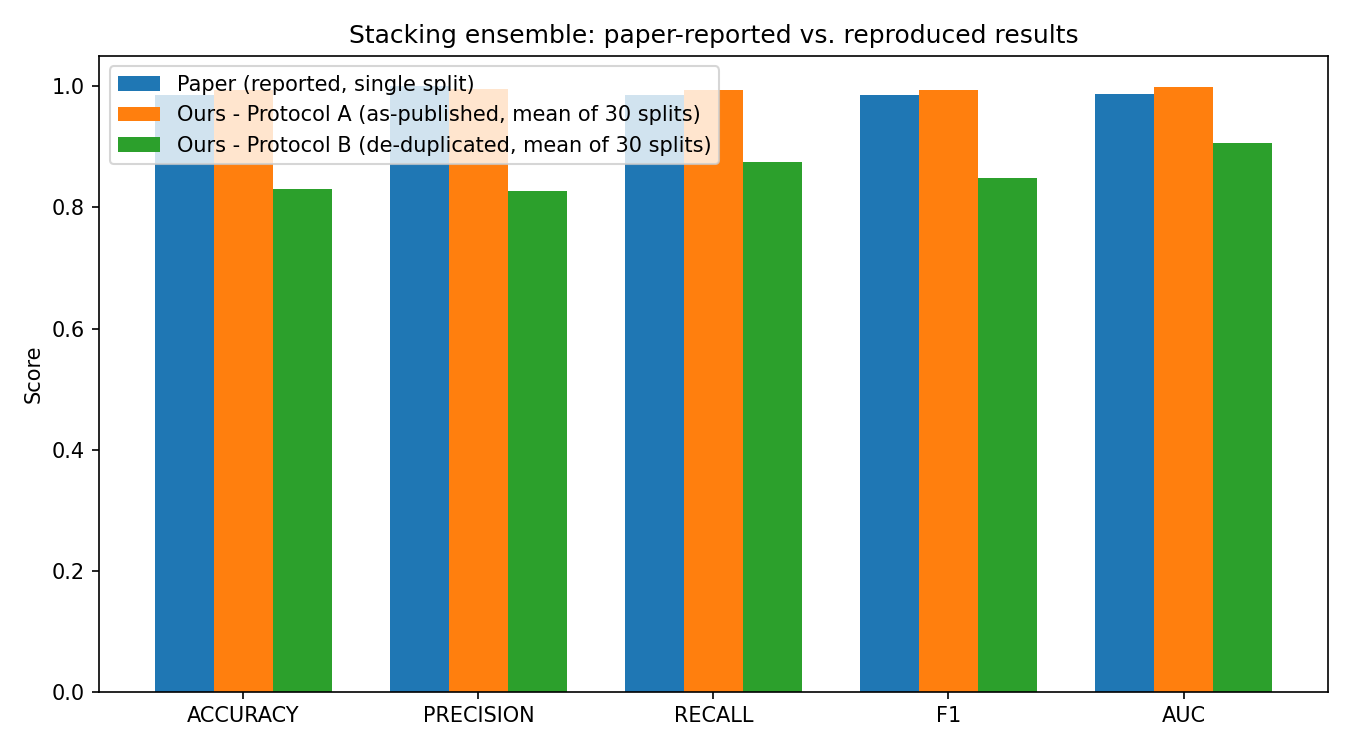

In [10]:
from IPython.display import Image, display
display(Image('../figures/paper_vs_reproduction_comparison.png'))

## Confusion matrices and ROC curves

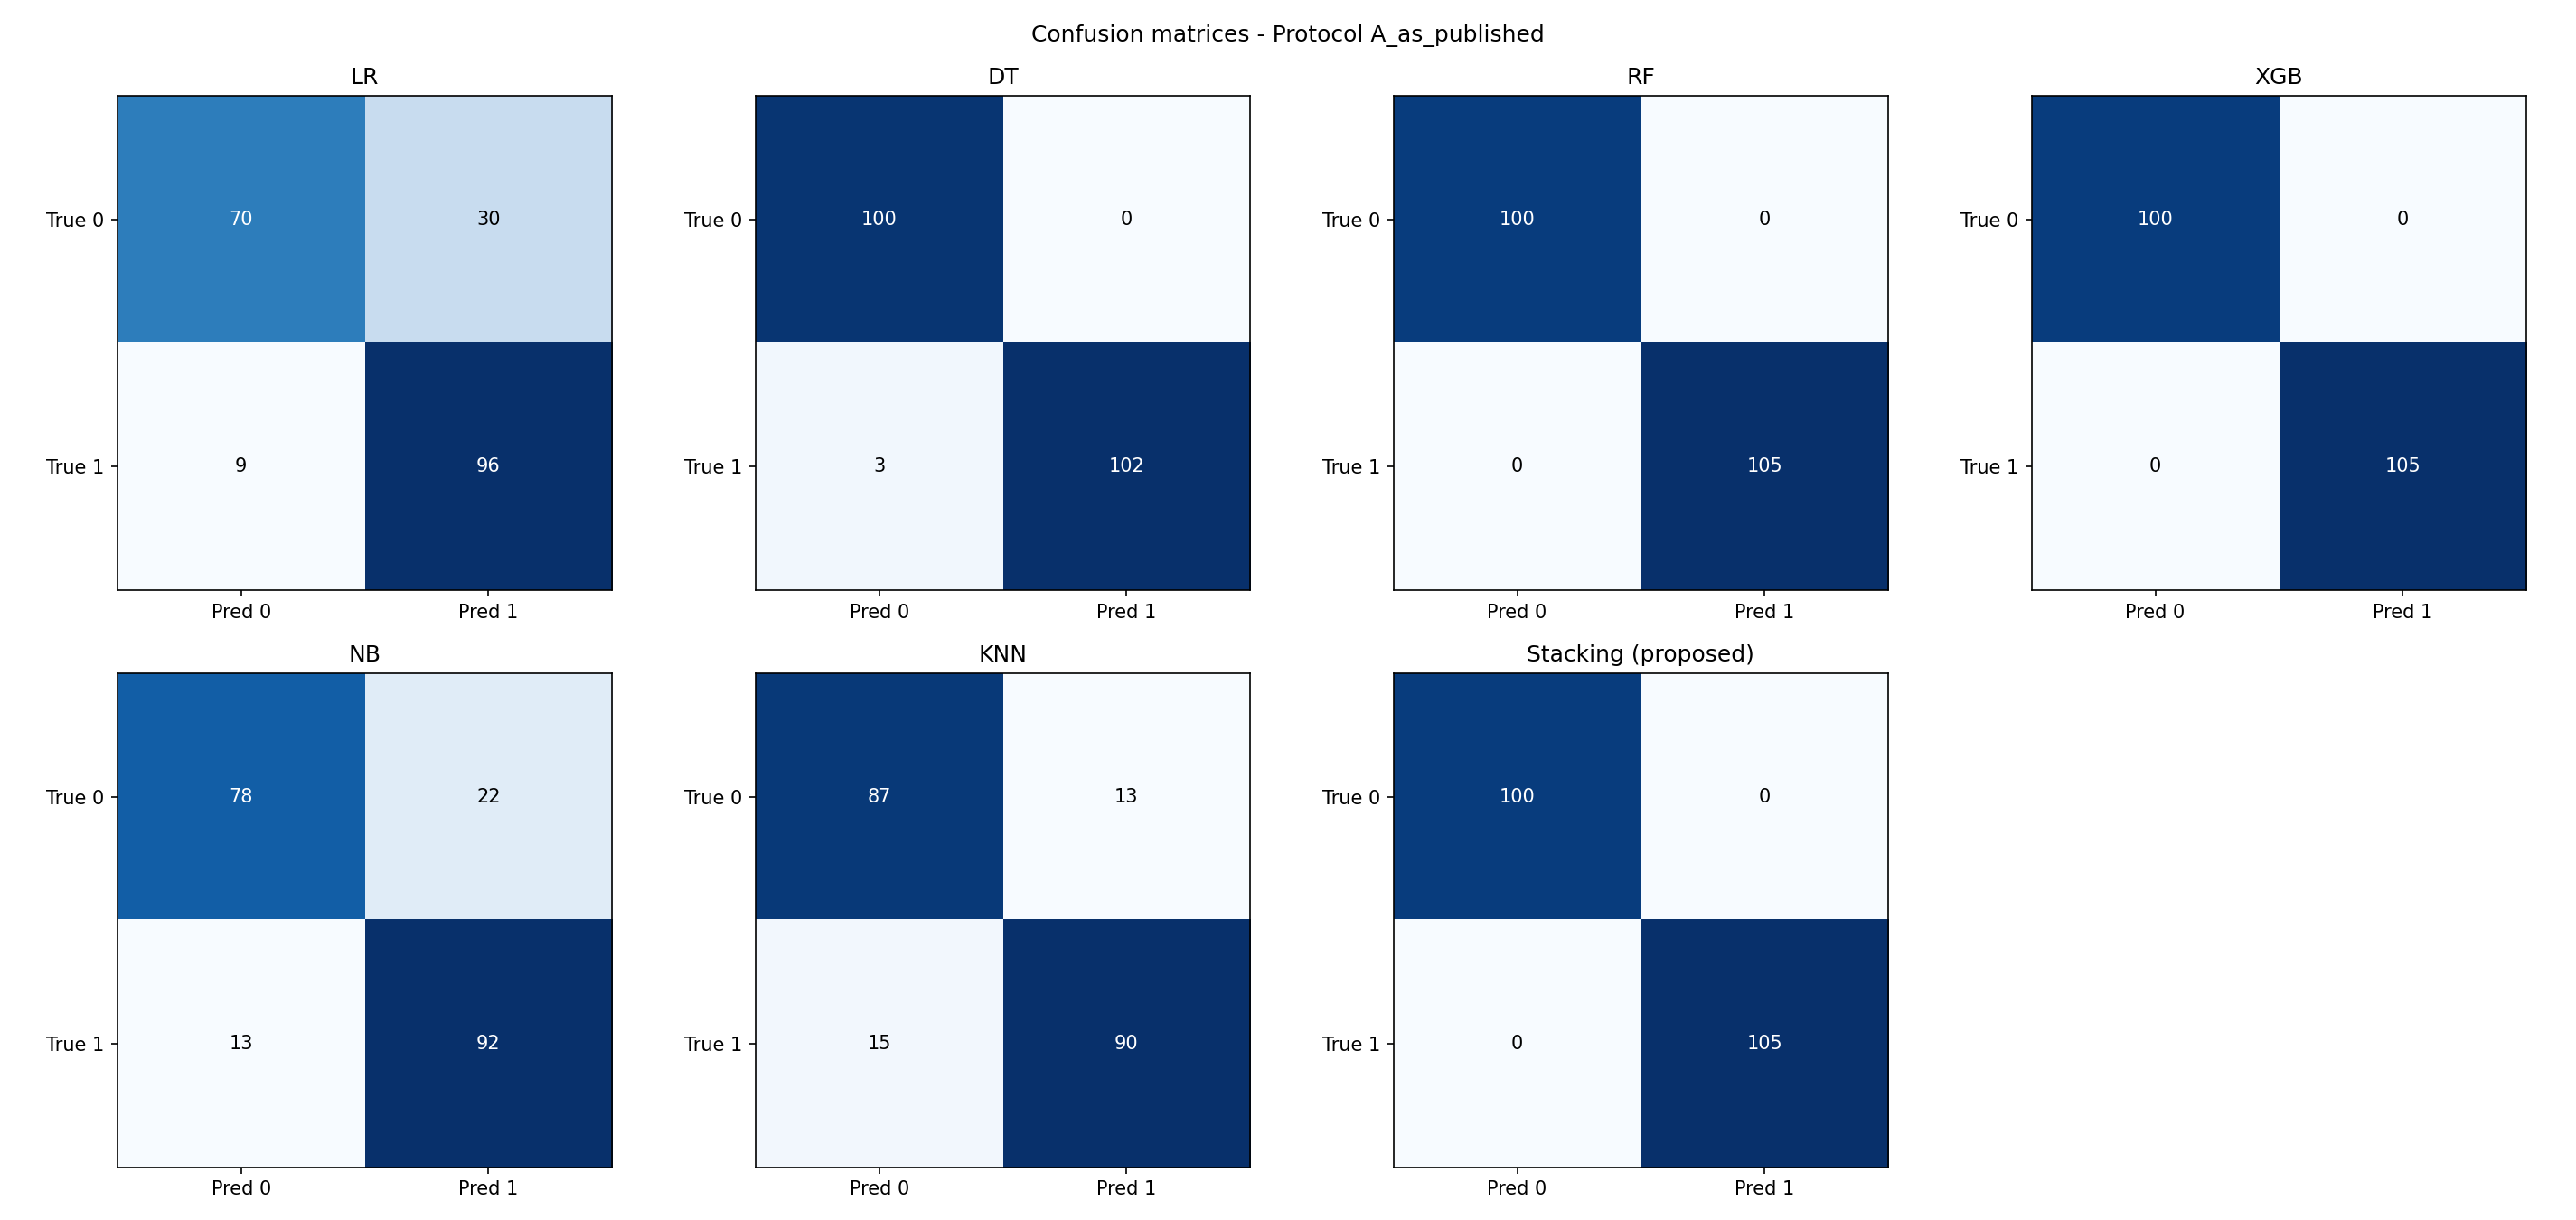

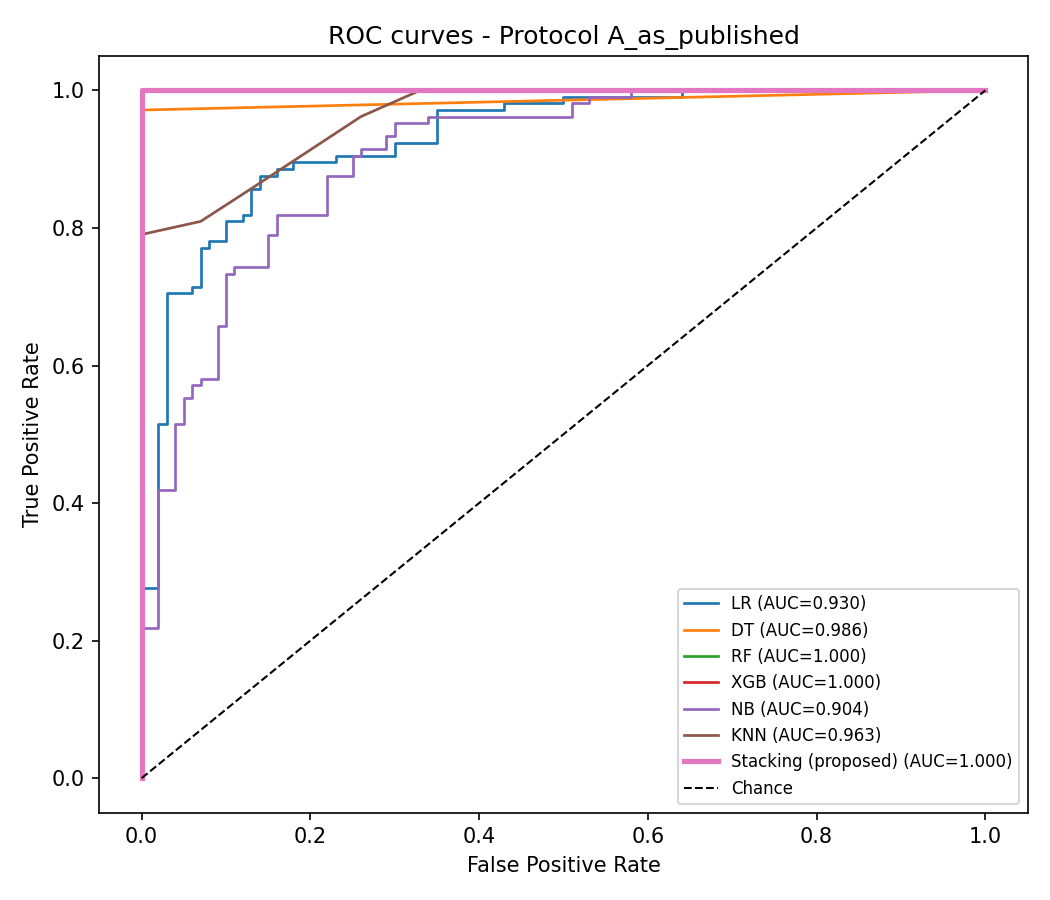

In [11]:
display(Image('../figures/confusion_matrices_A_as_published.png'))
display(Image('../figures/roc_curves_A_as_published.png'))

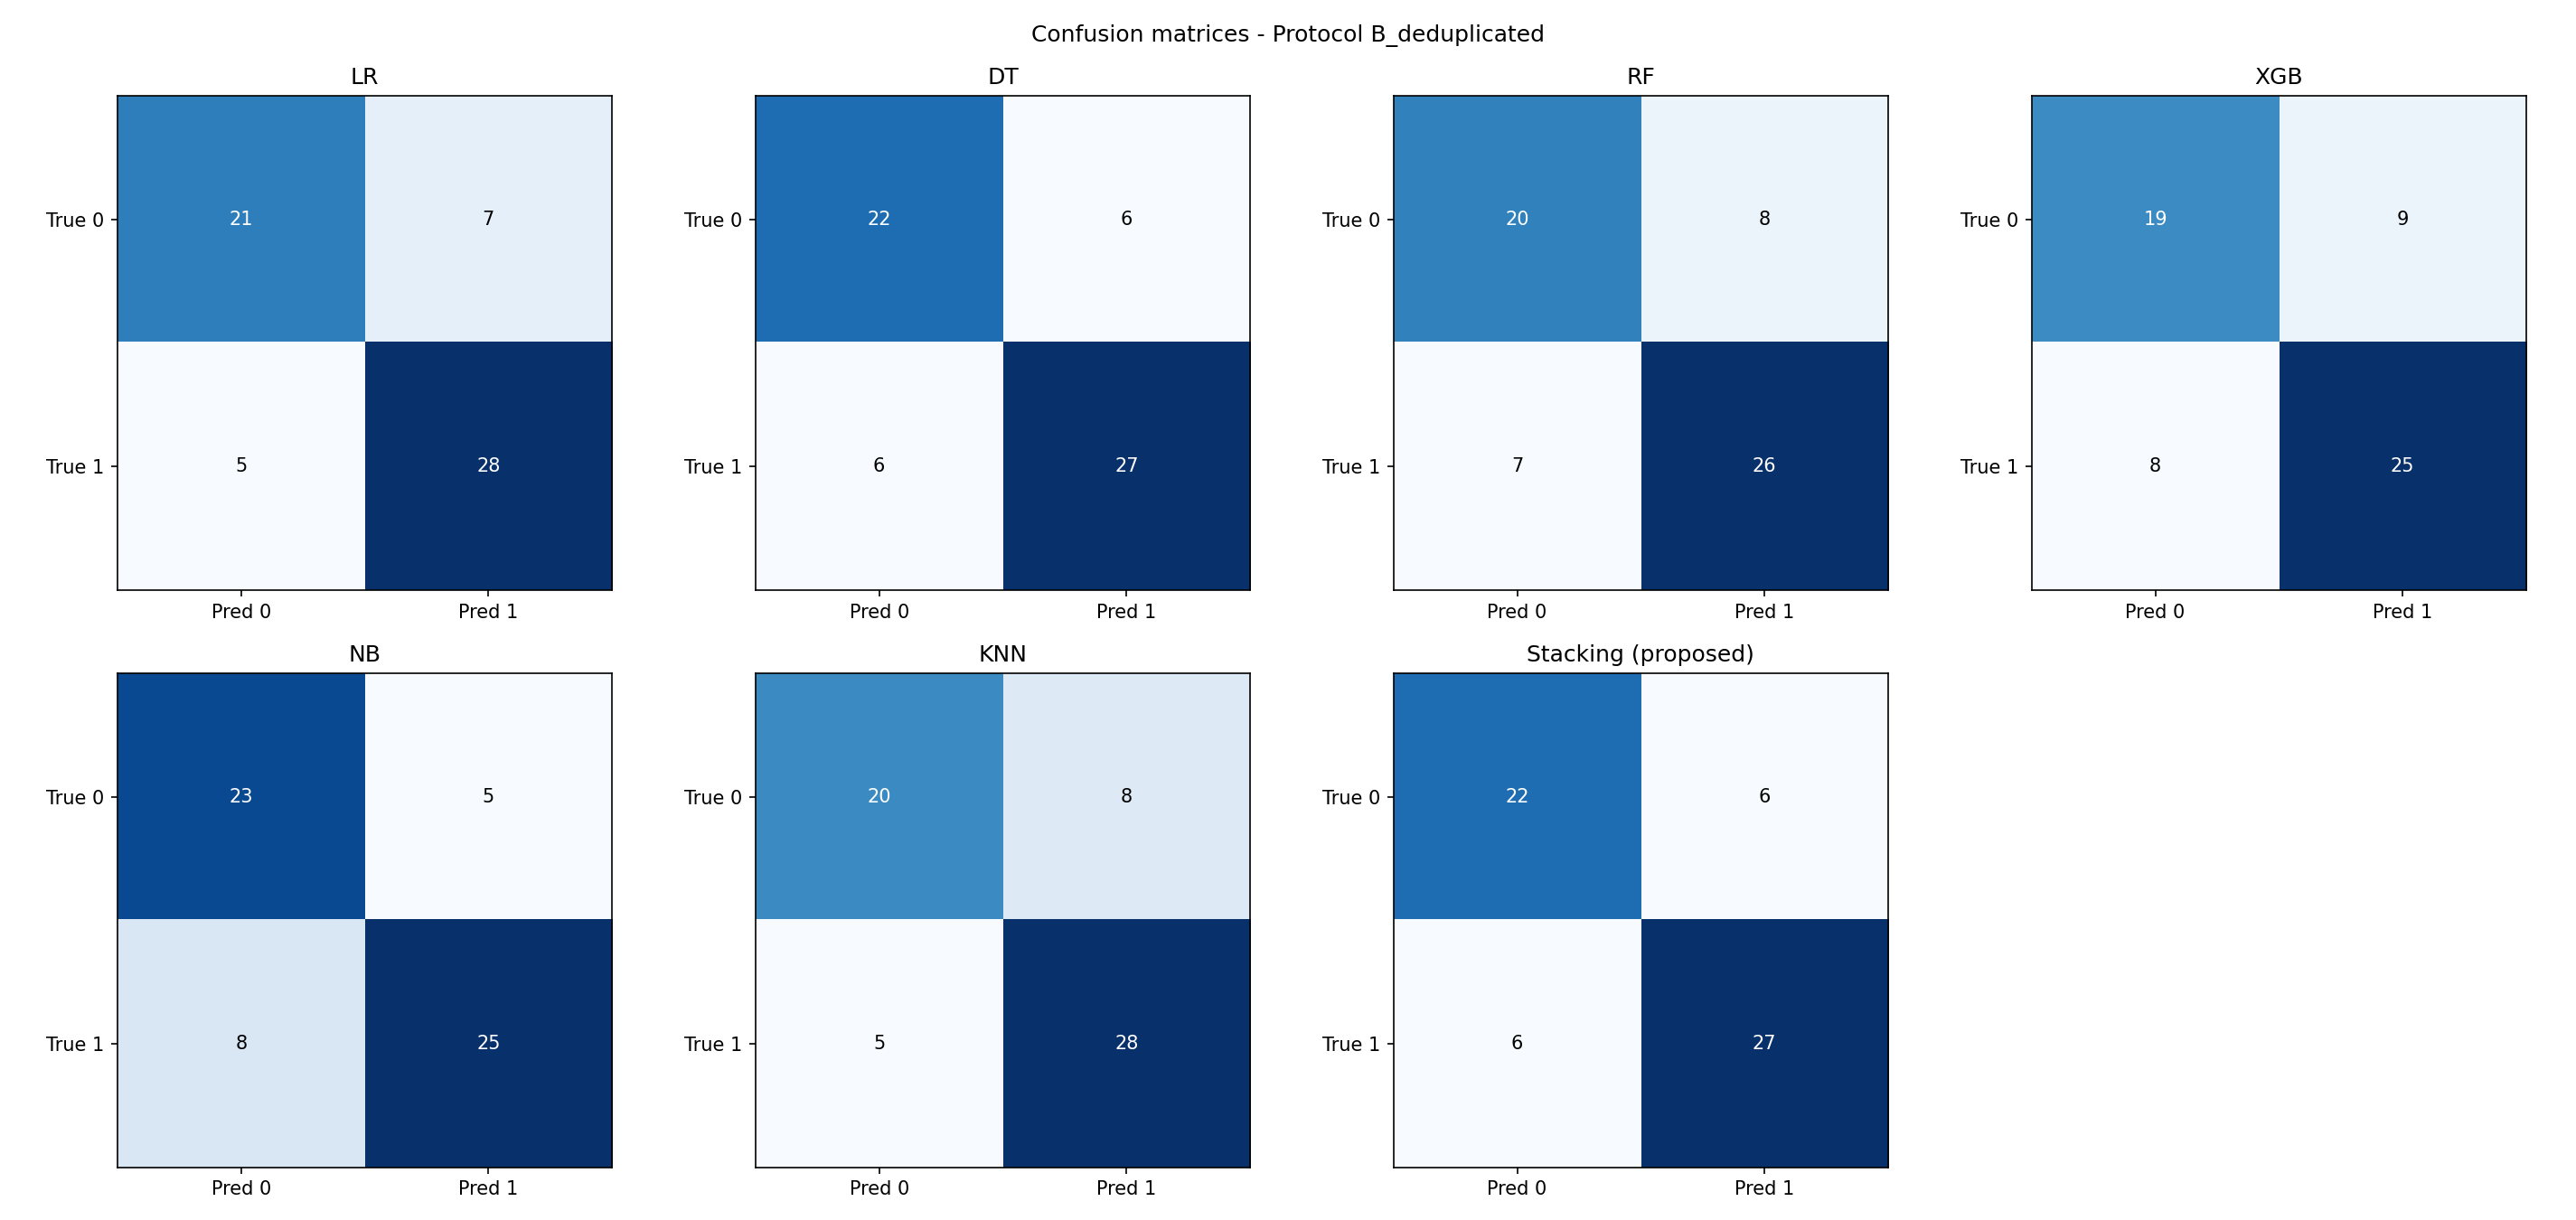

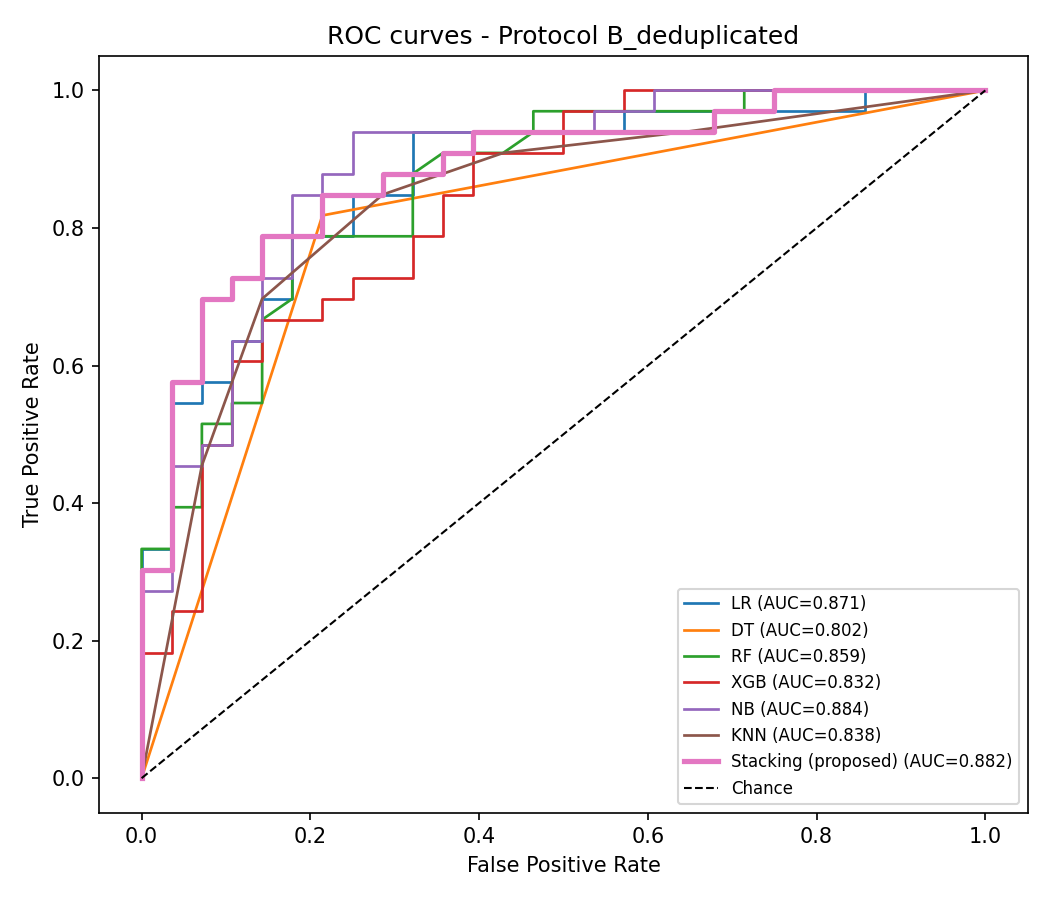

In [12]:
display(Image('../figures/confusion_matrices_B_deduplicated.png'))
display(Image('../figures/roc_curves_B_deduplicated.png'))

### Interpretation
Protocol A's stacking ensemble (99.4% mean accuracy over 30 splits) closely matches the paper's reported 98.53% accuracy. Protocol B, identical in every other respect, drops to ~83%. Since the only difference between A and B is whether duplicate rows are allowed to appear on both sides of the train/test split, this ~15-16 percentage point gap is best explained by data leakage rather than by any property of the stacking architecture itself. See the technical report Section 4 for the full critical analysis.